## import libraries

In [34]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import numpy as np
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb

## 1-Reading Data

In [35]:
data=pd.read_csv('pet_clinic_noshow.csv')

## 2-OverView On Data

In [36]:
data.head()

,pet_id,pet_type,Appointment_id,scheduled_day,Appointment_day,Age_of_owner,SMS_Recived,chronic_disease,vaccination_due,severity_level,previous_visits,emergency_case,mobility_issue,No-Show
0,6275,Rabbit,50000,2024-02-24,2024-03-01,43,1,0,0,1,7,0,0,No
1,1514,Cat,50001,2024-01-05,2024-01-11,47,1,0,1,1,2,1,0,No
2,3080,Dog,50002,2024-03-25,2024-04-07,32,1,1,0,2,1,0,0,No
3,8147,Cat,50003,2024-03-22,2024-03-29,51,1,0,0,1,6,0,0,No
4,8346,Dog,50004,2024-01-14,2024-01-16,23,0,0,0,3,7,0,1,No


In [37]:
data.columns

Index(['pet_id', 'pet_type', 'Appointment_id', 'scheduled_day',
       'Appointment_day', 'Age_of_owner', 'SMS_Recived', 'chronic_disease',
       'vaccination_due', 'severity_level', 'previous_visits',
       'emergency_case', 'mobility_issue', 'No-Show'],
      dtype='object')

In [38]:
data.shape

(1000, 14)

<p style="color:red;font-size:80px">preprocesssing data

## 3-Check in Values

In [39]:
for col in data.columns:
    print(col,'-->',data[col].unique())

pet_id --> [6275 1514 3080 8147 8346 1951 7501 6116 3358 1751 7611 7317 7948 3355
 5944 6540 9397 9721 9516 9925 2677 6734 2310 8490 6510 9586 4975 1875
 2319 3156 3748 8228 4969 3624 2435 8664 9348 4777 4865 2299 2642 9879
 2894 5992 4601 8257 3473 3368 3749 7210 4610 7250 7953 1439 7086 5321
 3995 8180 5501 5367 1881 9565 3851 4369 3934 2437 2641 3582 7523 6964
 7746 8499 3900 5477 6771 8342 4484 8801 6549 5766 8215 7359 3752 8116
 8933 2932 7473 4127 5368 6783 5834 8532 1927 3077 7855 8081 2725 8654
 4238 8464 6766 1173 5312 8173 9314 1546 2692 9934 7048 9090 3140 1737
 1327 8183 1272 7780 6388 1888 6914 2593 3144 1174 8287 6294 9944 6739
 2811 7449 9462 1551 6115 9419 5635 5699 2663 9947 3397 3581 8794 4686
 8040 3351 7237 7800 8559 9579 7020 3793 5289 1332 5632 6049 3284 9107
 1478 9135 5919 5893 3223 5784 1114 6260 1052 3226 9326 2885 5832 8578
 7207 2987 1718 6671 3946 4137 9500 9266 8187 3011 5335 4810 6514 5016
 4506 7246 8332 3718 8339 4689 6486 6718 8459 2036 2916 8661 7175 

## 4-drop ['pet_id','Appointment_id'] cols

In [40]:
data.drop(['pet_id','Appointment_id'],axis=1,inplace=True)

In [41]:
data.columns

Index(['pet_type', 'scheduled_day', 'Appointment_day', 'Age_of_owner',
       'SMS_Recived', 'chronic_disease', 'vaccination_due', 'severity_level',
       'previous_visits', 'emergency_case', 'mobility_issue', 'No-Show'],
      dtype='object')

## 5-Convert columns ['scheduled_day'], ['Appointment_day'] into--> to_datetime

In [42]:
data['scheduled_day'] = pd.to_datetime(data['scheduled_day'])
data['Appointment_day'] = pd.to_datetime(data['Appointment_day'])

## 6-Extract Features From data['Appointment_day'] , data['scheduled_day']

## 6.1-Calculate 'waiting_time' and update Data 

In [43]:
data['waiting_time'] = (data['Appointment_day'] - data['scheduled_day']).dt.days

print(data['waiting_time'].unique())

#Update Data
data = data[data['waiting_time'] >= 0]

[ 6 13  7  2 10  3 14  8  9 11 12  5  1  4]


In [44]:
print(data['waiting_time'].unique())

[ 6 13  7  2 10  3 14  8  9 11 12  5  1  4]


## 6.2 Calculate appointment_weekday

Do people tend to be absent more on Saturdays? Or on Fridays (if the clinic is open)?

In [45]:
data['appointment_weekday'] = data['Appointment_day'].dt.day_name()

## 6.3 Calculate Appointment_month

Are there specific months (like summer months or exam periods) when the rate of absenteeism increases?

In [46]:
data['appointment_month'] = data['Appointment_day'].dt.month

## 7-Drop  ['scheduled_day', 'Appointment_day'] cols

In [47]:
data.drop(['scheduled_day', 'Appointment_day'], axis=1, inplace=True)

## 8-Follow preprocessing Data

In [48]:
for col in data.columns:
    print(col,'-->',data[col].unique())

pet_type --> ['Rabbit' 'Cat' 'Dog' 'Bird']
Age_of_owner --> [43 47 32 51 23 50 41 18 44 27 54 19 56 36 45 68 60 28 74 24 21 46 35 26
 58 42 39 20 37 63 49 57 30 69 66 65 48 70 55 22 29 73 61 71 72 64 40 25
 67 59 38 33 52 34 62 31 53]
SMS_Recived --> [1 0]
chronic_disease --> [0 1]
vaccination_due --> [0 1]
severity_level --> [1 2 3]
previous_visits --> [7 2 1 6 9 5 0 4 3 8]
emergency_case --> [0 1]
mobility_issue --> [0 1]
No-Show --> ['No' 'Yes']
waiting_time --> [ 6 13  7  2 10  3 14  8  9 11 12  5  1  4]
appointment_weekday --> ['Friday' 'Thursday' 'Sunday' 'Tuesday' 'Monday' 'Wednesday' 'Saturday']
appointment_month --> [3 1 4 2]


In [49]:
for col in data.columns:
    print(col,'-->',data[col].dtype)

pet_type --> object
Age_of_owner --> int64
SMS_Recived --> int64
chronic_disease --> int64
vaccination_due --> int64
severity_level --> int64
previous_visits --> int64
emergency_case --> int64
mobility_issue --> int64
No-Show --> object
waiting_time --> int64
appointment_weekday --> object
appointment_month --> int32


## 8.1 Check Error Correction

In [50]:
print(sorted(data['Age_of_owner'].unique()))

[18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74]


## Logic Values

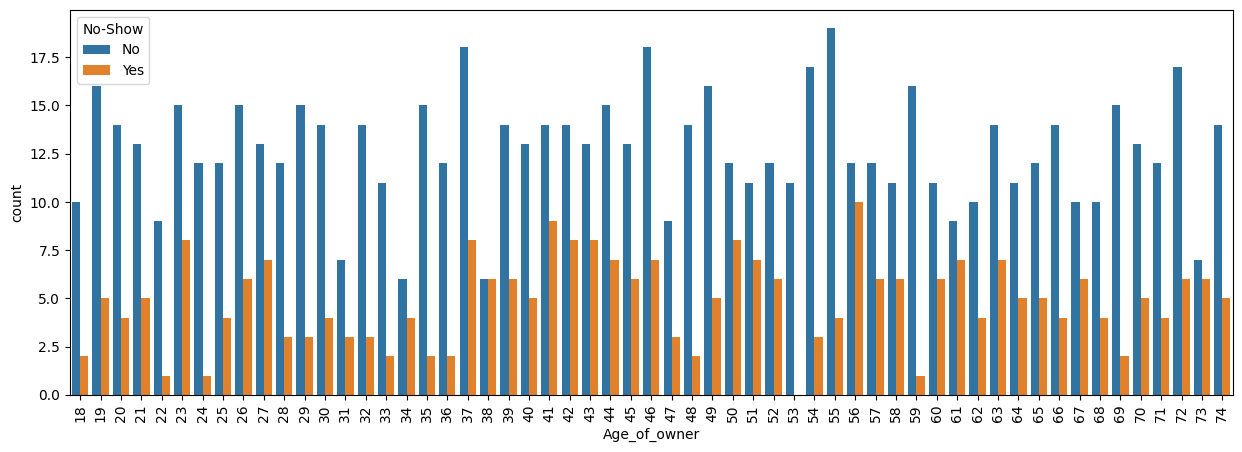

In [51]:
plt.figure(figsize=(15,5))
sns.countplot(x='Age_of_owner', hue='No-Show', data=data)
plt.xticks(rotation=90)
plt.show()

## 8.2 Check null Value

In [52]:
data.isna().sum()

pet_type               0
Age_of_owner           0
SMS_Recived            0
chronic_disease        0
vaccination_due        0
severity_level         0
previous_visits        0
emergency_case         0
mobility_issue         0
No-Show                0
waiting_time           0
appointment_weekday    0
appointment_month      0
dtype: int64

## 8.3 Check Duplicates

In [53]:
duplicate_count = data.duplicated().sum()
total_rows = len(data)
duplication_rate = (duplicate_count / total_rows) * 100

print(f"duplicate_count: {duplicate_count}")
print(f"duplication_rate: {duplication_rate:.2f}%")

duplicate_count: 0
duplication_rate: 0.00%


##  8.4 Encoding 

In [54]:
for col in data.columns:
    print(col,'-->',data[col].dtype)

pet_type --> object
Age_of_owner --> int64
SMS_Recived --> int64
chronic_disease --> int64
vaccination_due --> int64
severity_level --> int64
previous_visits --> int64
emergency_case --> int64
mobility_issue --> int64
No-Show --> object
waiting_time --> int64
appointment_weekday --> object
appointment_month --> int32


pet_type --> object

No-Show --> object

appointment_weekday --> object

In [55]:
cols_to_encode = ['pet_type', 'No-Show','appointment_weekday']
data = pd.get_dummies(data, columns=cols_to_encode, drop_first=True,dtype=int)
print(data.columns)

Index(['Age_of_owner', 'SMS_Recived', 'chronic_disease', 'vaccination_due',
       'severity_level', 'previous_visits', 'emergency_case', 'mobility_issue',
       'waiting_time', 'appointment_month', 'pet_type_Cat', 'pet_type_Dog',
       'pet_type_Rabbit', 'No-Show_Yes', 'appointment_weekday_Monday',
       'appointment_weekday_Saturday', 'appointment_weekday_Sunday',
       'appointment_weekday_Thursday', 'appointment_weekday_Tuesday',
       'appointment_weekday_Wednesday'],
      dtype='object')


In [56]:
for col in data.columns:
    print(col,' --> ',data[col].unique())

Age_of_owner  -->  [43 47 32 51 23 50 41 18 44 27 54 19 56 36 45 68 60 28 74 24 21 46 35 26
 58 42 39 20 37 63 49 57 30 69 66 65 48 70 55 22 29 73 61 71 72 64 40 25
 67 59 38 33 52 34 62 31 53]
SMS_Recived  -->  [1 0]
chronic_disease  -->  [0 1]
vaccination_due  -->  [0 1]
severity_level  -->  [1 2 3]
previous_visits  -->  [7 2 1 6 9 5 0 4 3 8]
emergency_case  -->  [0 1]
mobility_issue  -->  [0 1]
waiting_time  -->  [ 6 13  7  2 10  3 14  8  9 11 12  5  1  4]
appointment_month  -->  [3 1 4 2]
pet_type_Cat  -->  [0 1]
pet_type_Dog  -->  [0 1]
pet_type_Rabbit  -->  [1 0]
No-Show_Yes  -->  [0 1]
appointment_weekday_Monday  -->  [0 1]
appointment_weekday_Saturday  -->  [0 1]
appointment_weekday_Sunday  -->  [0 1]
appointment_weekday_Thursday  -->  [0 1]
appointment_weekday_Tuesday  -->  [0 1]
appointment_weekday_Wednesday  -->  [0 1]


In [57]:
for col in data.columns:
    print(col,' --> ',data[col].dtype)

Age_of_owner  -->  int64
SMS_Recived  -->  int64
chronic_disease  -->  int64
vaccination_due  -->  int64
severity_level  -->  int64
previous_visits  -->  int64
emergency_case  -->  int64
mobility_issue  -->  int64
waiting_time  -->  int64
appointment_month  -->  int32
pet_type_Cat  -->  int32
pet_type_Dog  -->  int32
pet_type_Rabbit  -->  int32
No-Show_Yes  -->  int32
appointment_weekday_Monday  -->  int32
appointment_weekday_Saturday  -->  int32
appointment_weekday_Sunday  -->  int32
appointment_weekday_Thursday  -->  int32
appointment_weekday_Tuesday  -->  int32
appointment_weekday_Wednesday  -->  int32


## End Encoding----

## 9-We'll think about how to deal with the neighborhood leader.

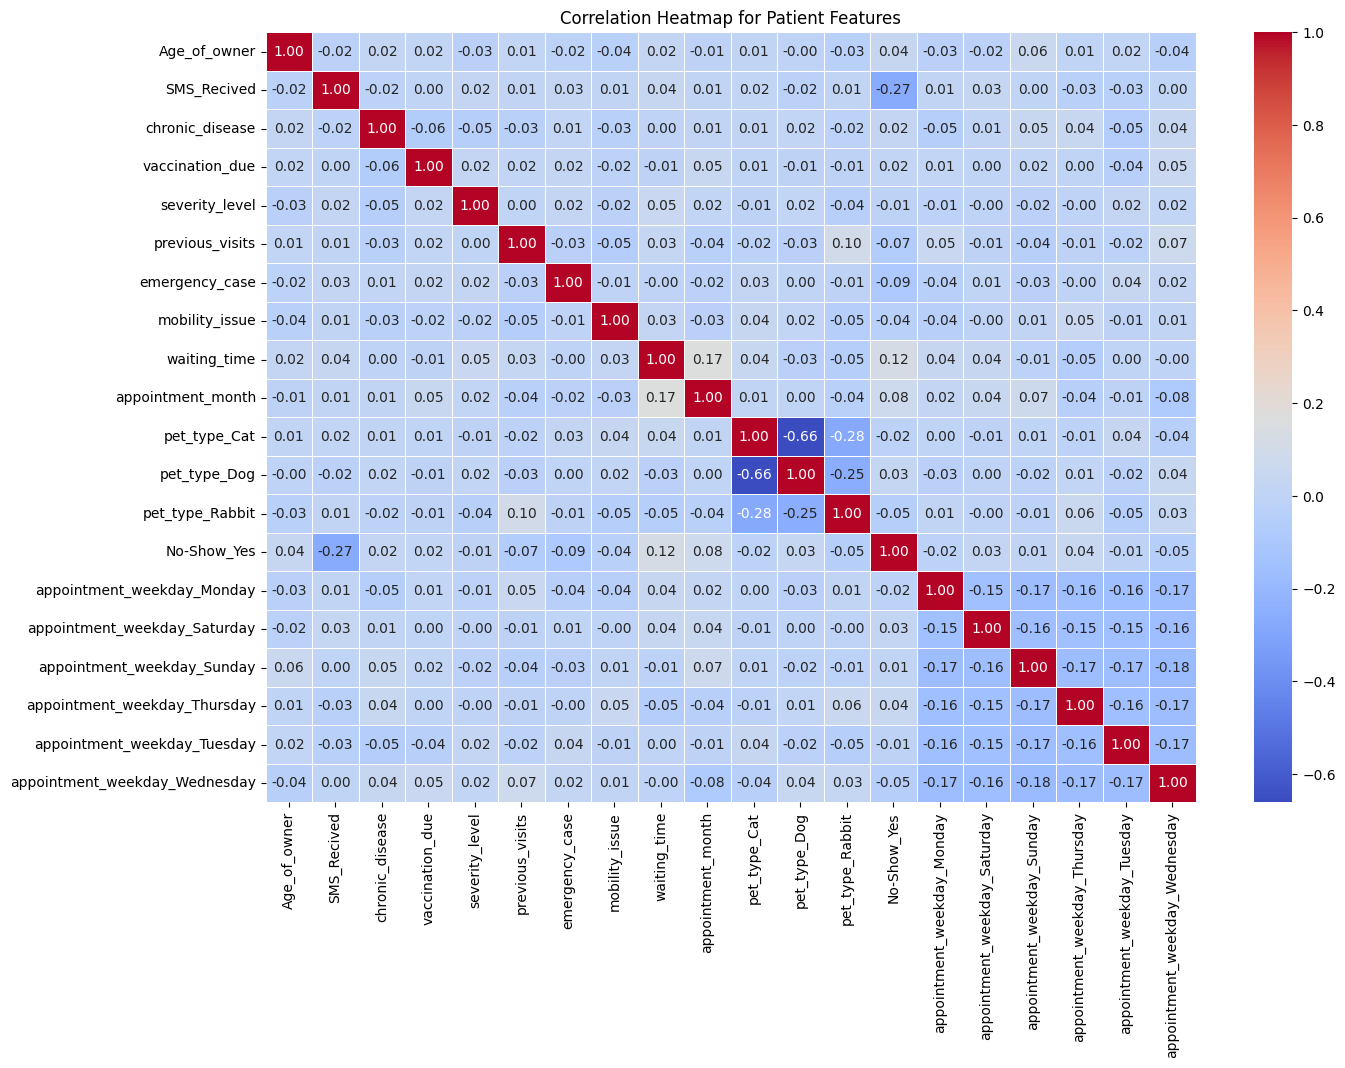

In [58]:
corr_matrix = data.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap for Patient Features')
plt.show()

In [59]:
data.shape

(1000, 20)

In [60]:
data.columns

Index(['Age_of_owner', 'SMS_Recived', 'chronic_disease', 'vaccination_due',
       'severity_level', 'previous_visits', 'emergency_case', 'mobility_issue',
       'waiting_time', 'appointment_month', 'pet_type_Cat', 'pet_type_Dog',
       'pet_type_Rabbit', 'No-Show_Yes', 'appointment_weekday_Monday',
       'appointment_weekday_Saturday', 'appointment_weekday_Sunday',
       'appointment_weekday_Thursday', 'appointment_weekday_Tuesday',
       'appointment_weekday_Wednesday'],
      dtype='object')

___________

<p style="color:red;font-size:80px">Training Model

In [61]:
# !pip install xgboost

In [62]:
X = data[['Age_of_owner', 'SMS_Recived', 'chronic_disease', 'vaccination_due', 
          'severity_level', 'previous_visits', 'emergency_case', 'mobility_issue', 
          'waiting_time', 'appointment_month', 'pet_type_Cat', 'pet_type_Dog', 
          'pet_type_Rabbit', 'appointment_weekday_Monday', 'appointment_weekday_Saturday', 
          'appointment_weekday_Sunday', 'appointment_weekday_Thursday', 
          'appointment_weekday_Tuesday', 'appointment_weekday_Wednesday']]

y = data['No-Show_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [63]:
model = xgb.XGBClassifier(
    n_estimators=100,      
    learning_rate=0.1,     
    max_depth=5,           
    use_label_encoder=False,
    eval_metric='logloss'
)


model.fit(X_train, y_train)

y_pred = model.predict(X_test)

c:\Users\za813\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:12:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy Score: 0.72

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.88      0.82       145
           1       0.48      0.29      0.36        55

    accuracy                           0.72       200
   macro avg       0.63      0.59      0.59       200
weighted avg       0.69      0.72      0.69       200

Confusion Matrix:
 [[128  17]
 [ 39  16]]


<Figure size 1000x600 with 0 Axes>

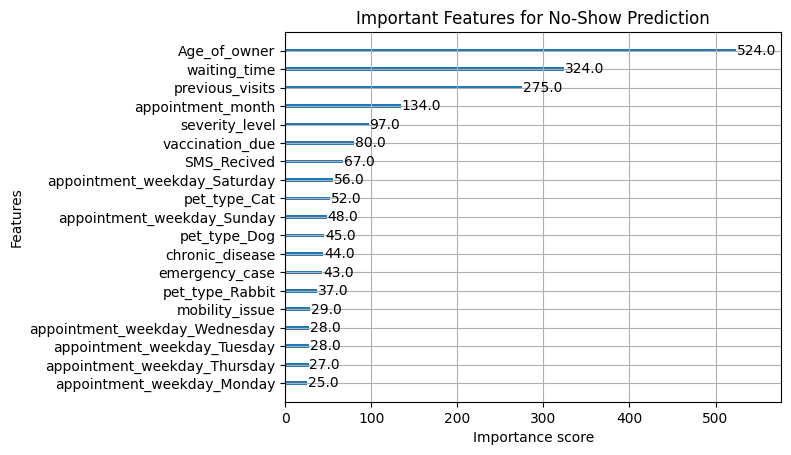

In [64]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='weight')
plt.title('Important Features for No-Show Prediction')
plt.show()

In [ ]:
import joblib

joblib.dump(model, 'model.pkl')
joblib.dump(X.columns, 'columns.pkl')  

['columns.pkl']